# TableEmbedJePA — Development Sanity Check

Step-by-step verification of every pipeline component:

| § | What is checked |
|---|---|
| 1 | Config loading (no Hydra) |
| 2 | Dataset creation, U-path count, `__getitem__` shapes |
| 3 | Dataloader batch shapes and mask structure |
| 4 | Model architecture, parameter count, forward pass |
| 5 | Mini training run (3 epochs) — loss should decrease |
| 6 | Inference mode — cosine ranking of U-paths against a question |

> **Dependencies:** `torch`, `pytorch_lightning`, `sentence_transformers`, `omegaconf`  
> Run from the repo root **or** from inside `TRL-model/`.

In [1]:
# ── § 0  Setup ────────────────────────────────────────────────────────────────
import sys, json, tempfile, pathlib
import torch
import torch.nn.functional as F

# Locate TRL-model/ regardless of where the notebook is launched from
_HERE = pathlib.Path().resolve()
_TRL  = _HERE if (_HERE / "dataset.py").exists() else _HERE / "TRL-model"
for _p in [str(_TRL), str(_TRL.parent)]:
    if _p not in sys.path:
        sys.path.insert(0, _p)

print(f"TRL-model root : {_TRL}")
print(f"PyTorch        : {torch.__version__}")
DEVICE = "cuda" if torch.cuda.is_available() else "cpu"
print(f"Device         : {DEVICE}")

# Use Tensor Cores on NVIDIA GPUs (trades negligible precision for significant speed)
if DEVICE == "cuda":
    torch.set_float32_matmul_precision("high")
    print(f"float32 matmul : high  (Tensor Core optimised — {torch.cuda.get_device_name(0)})")


TRL-model root : C:\Users\wtchuitc\Documents\GitHub\UTUEL\TRL-model
PyTorch        : 2.5.1
Device         : cuda
float32 matmul : high  (Tensor Core optimised — NVIDIA RTX A4000 Laptop GPU)


## § 1 — Config
Load `config.yaml` directly with OmegaConf (no Hydra required in a notebook).

In [2]:
from omegaconf import OmegaConf

cfg = OmegaConf.load(str(_TRL / "config.yaml"))
print(OmegaConf.to_yaml(cfg))

model:
  hidden_size: 128
  num_layers: 3
  num_heads: 4
  intermediate_size: null
  attention_dropout: 0.1
  hidden_dropout: 0.1
  layer_norm_eps: 1.0e-12
  temperature: 0.07
  beta: 0.5
  ema_decay: 0.996
  ablate_proj: true
loss:
  jepa: 1.0
  local: 0.0
  global: 0.0
data:
  path: D:\TABLE_DATASET\WIKI_TABLE_SQL\test_lookup_test_jepa_arch.jsonl
  max_records: null
embedder:
  model_type: huggingface
  base_url: http://134.184.22.126:10434/
  model_name: sentence-transformers/all-MiniLM-L6-v2
  api_key: null
  precompute: true
  embed_batch_size: 64
  embed_dim: 128
smp:
  use_graph_walks: false
  num_walks: 50
  chunk_size: 1
training:
  mode: global
  output_dir: TRL-model/checkpoints
  epochs: 100
  batch_size: 16
  lr: 0.0001
  weight_decay: 0.01
  max_grad_norm: 1.0
  fp16: false
  bf16: false
  dataloader_num_workers: 4
  logging_steps: 10
  save_total_limit: 3
  seed: 42



## § 2 — Dataset & U-paths

Set `DATASET_URL` to either a **local file path** or a **remote URL** (raw GitHub, S3, etc.).  
Remote files are streamed and cached under `datasets_TRL/` so subsequent runs skip the download.  
Set `MAX_RECORDS = None` to load everything, or an integer to cap for quick iteration.

In [3]:
# ── Dataset source ────────────────────────────────────────────────────────────
# Either a local file path  : "D:\\data\\qa.jsonl"  or  "/home/user/data/qa.jsonl"
# Or a remote URL           : "https://example.com/data/qa.jsonl"
DATASET_URL  = "D:\\TABLE_DATASET\\WIKI_TABLE_SQL\\test_lookup_test_jepa_arch.jsonl"
MAX_RECORDS  = 200     # int to cap records for fast iteration; None = load all

# ── Resolve source → local path ───────────────────────────────────────────────
import urllib.request, shutil

_src = DATASET_URL.strip()
_is_url = _src.startswith("http://") or _src.startswith("https://")

if _is_url:
    _datasets_dir = _TRL.parent / "datasets_TRL"
    _datasets_dir.mkdir(exist_ok=True)
    _fname      = pathlib.Path(_src.split("?")[0]).name   # strip query params
    _local_path = _datasets_dir / _fname

    if not _local_path.exists():
        print(f"Downloading {_src} …")
        with urllib.request.urlopen(_src, timeout=60) as resp, \
             _local_path.open("wb") as out:
            shutil.copyfileobj(resp, out)
        print(f"Saved → {_local_path}  ({_local_path.stat().st_size / 1024:.1f} KB)")
    else:
        print(f"Using cached file: {_local_path}  ({_local_path.stat().st_size / 1024:.1f} KB)")
else:
    _local_path = pathlib.Path(_src)
    if not _local_path.exists():
        raise FileNotFoundError(f"Local path not found: {_local_path}")
    print(f"Using local file: {_local_path}  ({_local_path.stat().st_size / 1024:.1f} KB)")

# ── Count available records ───────────────────────────────────────────────────
with _local_path.open(encoding="utf-8") as fh:
    _total = sum(1 for ln in fh if ln.strip())

_data_path = _local_path
print(f"Total records in file : {_total}")
print(f"Records to use        : {MAX_RECORDS if MAX_RECORDS else _total}")

Using local file: D:\TABLE_DATASET\WIKI_TABLE_SQL\test_lookup_test_jepa_arch.jsonl  (21.6 KB)
Total records in file : 10
Records to use        : 200


In [4]:
from dataset import TableEmbedJePADataset, jepa_collate_fn

# all-MiniLM-L6-v2: 384-d, downloads once, runs locally — no API key needed
EMBED_MODEL = "sentence-transformers/all-MiniLM-L6-v2"

ds = TableEmbedJePADataset(
    jsonl_path=_data_path,
    model_type="huggingface",
    model_name=EMBED_MODEL,
    api_key=None,          # no key → local sentence_transformers
    max_records=MAX_RECORDS,
    precompute=True,
    embed_batch_size=64,
    use_graph_walks=False,
)

EMBED_DIM = ds.embed_dim
print(f"\nRecords loaded  : {len(ds.records)}")
print(f"U-path samples  : {len(ds)}")
print(f"embed_dim       : {EMBED_DIM}")

# Inspect one sample
sample = ds[0]
print("\n__getitem__[0] keys:")
for k, v in sample.items():
    desc = f"shape={v.shape}  dtype={v.dtype}" if isinstance(v, torch.Tensor) else repr(v)
    print(f"  {k:20s}  {desc}")

[dataset][load] 10 records from test_lookup_test_jepa_arch.jsonl
[dataset][smp_gen] 3135 U-path samples from 10 records
[dataset][embed_nodes] 416 unique node texts (batch_size=64)...
[dataset][embed] 416/416  (100.0%)
[dataset][embed_questions] 10 question embeddings...
[dataset][embed] 10/10  (100.0%)
[dataset][build_index] done  embed_dim=384

Records loaded  : 10
U-path samples  : 3135
embed_dim       : 384

__getitem__[0] keys:
  smp_embeds            shape=torch.Size([4, 384])  dtype=torch.float32
  query_embeds          shape=torch.Size([3, 384])  dtype=torch.float32
  question_emb          shape=torch.Size([384])  dtype=torch.float32
  record_idx            0
  upath                 UPath(row_idx=0, col_idx_a=0, col_idx_b=1, col_header_a='Player', cell_value_a='Aleksandar Radojević', cell_value_b='25', col_header_b='No.', tbl_row=1, pivot_a='0,0', node_a='1,0', node_b='1,1', pivot_b='0,1', smp_text='Player | Aleksandar Radojević | 25 | No.', reversed_smp_text='No. | 25 | Aleksa

In [5]:
# ── Inspect a few U-paths from record 0 ──────────────────────────────────────
upaths = ds.get_table_upaths(record_idx=0)
print(f"U-paths for record 0: {len(upaths)}\n")
print(f"{'col_header_a':>15} | {'cell_value_a':>12} | {'cell_value_b':>12} | {'col_header_b':>15}")
print("-" * 65)
for up in upaths[:8]:
    print(f"{up.col_header_a:>15} | {up.cell_value_a:>12} | {up.cell_value_b:>12} | {up.col_header_b:>15}")

U-paths for record 0: 120

   col_header_a | cell_value_a | cell_value_b |    col_header_b
-----------------------------------------------------------------
         Player | Aleksandar Radojević |           25 |             No.
         Player | Aleksandar Radojević |       Serbia |     Nationality
         Player | Aleksandar Radojević |       Center |        Position
         Player | Aleksandar Radojević |    1999-2000 | Years in Toronto
         Player | Aleksandar Radojević | Barton CC (KS) | School/Club Team
            No. |           25 |       Serbia |     Nationality
            No. |           25 |       Center |        Position
            No. |           25 |    1999-2000 | Years in Toronto


## § 3 — Dataloader

Verify all batch tensor shapes and the structure of `MASK_SMP_LEVEL_LOSS`.

In [6]:
from torch.utils.data import DataLoader

BATCH_SIZE = 4

loader = DataLoader(
    ds,
    batch_size=BATCH_SIZE,
    shuffle=True,
    drop_last=True,          # required: batch must be exactly B
    collate_fn=jepa_collate_fn,
)

batch = next(iter(loader))

print("Batch tensor shapes:")
for k, v in batch.items():
    print(f"  {k:25s}  shape={str(v.shape):<20}  dtype={v.dtype}")

B = BATCH_SIZE
M = batch["MASK_SMP_LEVEL_LOSS"]   # [2B, 2B]
print(f"\nMASK_SMP_LEVEL_LOSS [{2*B}x{2*B}]:")
print(M)
print(f"\nPositive pairs (value=1.0): {(M == 1).sum().item()}")
print(f"Diagonal entries  (value=4.0): {(M == 4).sum().item()}")
print(f"Negative pairs    (value=0.0): {(M == 0).sum().item()}")

Batch tensor shapes:
  smp_embeds                 shape=torch.Size([4, 4, 384])  dtype=torch.float32
  smp_bar_embeds             shape=torch.Size([4, 4, 384])  dtype=torch.float32
  query_embeds               shape=torch.Size([4, 3, 384])  dtype=torch.float32
  MASK_SMP_LEVEL_LOSS        shape=torch.Size([8, 8])    dtype=torch.float32
  question_embeds            shape=torch.Size([4, 384])  dtype=torch.float32
  record_indices             shape=torch.Size([4])       dtype=torch.int64

MASK_SMP_LEVEL_LOSS [8x8]:
tensor([[4., 0., 0., 0., 1., 0., 0., 0.],
        [0., 4., 0., 0., 0., 1., 0., 0.],
        [0., 0., 4., 0., 0., 0., 1., 0.],
        [0., 0., 0., 4., 0., 0., 0., 1.],
        [1., 0., 0., 0., 4., 0., 0., 0.],
        [0., 1., 0., 0., 0., 4., 0., 0.],
        [0., 0., 1., 0., 0., 0., 4., 0.],
        [0., 0., 0., 1., 0., 0., 0., 4.]])

Positive pairs (value=1.0): 8
Diagonal entries  (value=4.0): 8
Negative pairs    (value=0.0): 48


## § 4 — Model architecture & forward pass

We use a **small config** (`hidden_size=64, num_layers=2`) so the forward pass runs fast on CPU.

In [7]:
from config import TableEmbedJePAConfig
from model  import TableEmbedJePA

# ── Ablation flag ─────────────────────────────────────────────────────────────
# ABLATE_PROJ = True  → input_projection is replaced with nn.Identity (no-op).
# Requires HIDDEN == EMBED_DIM so no dimension mismatch enters the transformer.
HIDDEN      = EMBED_DIM   # 384 — matches embed dim; projection becomes square / ablatable
ABLATE_PROJ = True        # set False to use the learned linear projection

model_cfg = TableEmbedJePAConfig(
    hidden_size=HIDDEN,
    num_hidden_layers=2,
    num_attention_heads=4,       # must divide HIDDEN (384 / 4 = 96 ✓)
    intermediate_size=HIDDEN * 4,
    attention_probs_dropout_prob=0.0,
    hidden_dropout_prob=0.0,
    embedding_dim=EMBED_DIM,     # input projection: EMBED_DIM → HIDDEN (square)
    tempeture=0.07,
    beta=0.5,
)

model = TableEmbedJePA(
    config=model_cfg,
    lr=1e-3,
    weight_decay=1e-2,
    max_epochs=6,
    ema_decay=0.996,
    jepa_weight=1.0,
    local_weight=1.0,
    global_weight=1.0,
    ablate_proj=ABLATE_PROJ,
).to(DEVICE)

if ABLATE_PROJ:
    print(f"ABLATE_PROJ=True  →  input_projection replaced with nn.Identity (d={HIDDEN})")

n_total  = sum(p.numel() for p in model.parameters())
n_train  = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(f"Trainable params : {n_train:,}  /  Total: {n_total:,}")
print(f"  (target_encoder shares weights via EMA — its params are frozen)\n")
print("Per-submodule parameter counts:")
for name, mod in model.named_children():
    n = sum(p.numel() for p in mod.parameters())
    print(f"  {name:30s}  {n:>8,}")


Trainable params : 158,272  /  Total: 258,240
  (target_encoder shares weights via EMA — its params are frozen)

Per-submodule parameter counts:
  input_projection                  24,640
  transformer_encoder               99,968
  target_encoder                    99,968
  predictor                         33,600


In [8]:
# ── Single forward pass (no grad) ────────────────────────────────────────────
batch_dev = {k: v.to(DEVICE) for k, v in batch.items()}

model.eval()
with torch.no_grad():
    out = model(
        smp_embeds    = batch_dev["smp_embeds"],      # [B, 4, d_in]
        smp_bar_embeds= batch_dev["smp_bar_embeds"],  # [B, 4, d_in]
        query_embeds  = batch_dev["query_embeds"],    # [B, 3, d_in]
    )

print("Output fields:")
print(f"  loss         = {out.loss.item():.4f}   (total weighted)")
print(f"  jepa_loss    = {out.jepa_loss.item():.4f}")
print(f"  local_loss   = {out.local_loss.item():.4f}")
print(f"  global_loss  = {out.global_loss.item():.4f}")
print(f"  logits       shape={out.logits.shape}   (online encoder output [B,5,d_out])")
if out.attentions is not None:
    print(f"  attentions   shape={out.attentions.shape}")

Output fields:
  loss         = 4.2203   (total weighted)
  jepa_loss    = 2.2964
  local_loss   = 0.0004
  global_loss  = 1.9234
  logits       shape=torch.Size([4, 5, 64])   (online encoder output [B,5,d_out])
  attentions   shape=torch.Size([8, 4, 5, 5])


## § 5 — Mini training run

3 epochs on the synthetic dataset.  
**Expected**: `train_loss` should decrease each epoch.

In [ ]:
import pytorch_lightning as pl
import tempfile
from dataset import TableEmbedJePADataModule
from pytorch_lightning.callbacks import EarlyStopping, ModelCheckpoint

_seen_tids, _table_ids = set(), []
for _rec in ds.records:
    _tid = str(_rec.get("table_id", ""))
    if _tid not in _seen_tids:
        _seen_tids.add(_tid)
        _table_ids.append(_tid)

print(f"[train][per_table] {len(_table_ids)} distinct tables found")
print(f"  ABLATE_PROJ={ABLATE_PROJ}  →  "
      f"{'input_projection = Identity (no learned projection)' if ABLATE_PROJ else 'input_projection active'}\n")

_MAX_EPOCHS   = 10
_PER_TABLE_LR = 1e-4
_PATIENCE     = 3      # early stopping: epochs without improvement on train_loss_epoch
_NUM_WORKERS  = 4

def _make_model():
    return TableEmbedJePA(
        config=model_cfg, lr=_PER_TABLE_LR, weight_decay=1e-2,
        max_epochs=_MAX_EPOCHS, ema_decay=0.996,
        jepa_weight=1.0, jepa_bar_weight=1.0, local_weight=1.0, global_weight=1.0,
        ablate_proj=ABLATE_PROJ,
    )

def _make_trainer(ckpt_dir: str):
    _es = EarlyStopping(
        monitor="train_loss_epoch", patience=_PATIENCE, mode="min", verbose=False)
    _ckpt = ModelCheckpoint(
        dirpath=ckpt_dir, monitor="train_loss_epoch", mode="min",
        save_top_k=1, filename="best")
    _trainer = pl.Trainer(
        max_epochs=_MAX_EPOCHS,
        enable_checkpointing=False,
        logger=False,
        enable_progress_bar=True,
        accelerator=DEVICE if DEVICE != "cpu" else "cpu",
        gradient_clip_val=1.0,
        gradient_clip_algorithm="norm",
        callbacks=[_es, _ckpt],
    )
    return _trainer, _ckpt

_dm_kwargs = dict(
    batch_size=BATCH_SIZE,
    num_workers=_NUM_WORKERS,
    model_type="huggingface",
    model_name=EMBED_MODEL,
    api_key=None,
    precompute=True,
    embed_batch_size=64,
)

train_models: dict[str, TableEmbedJePA] = {}

for _i, _tid in enumerate(_table_ids, 1):
    _dm = TableEmbedJePADataModule(jsonl_path=_data_path, filter_table_id=_tid, **_dm_kwargs)
    _dm.setup()
    _n = len(_dm._dataset)
    if _n < BATCH_SIZE:
        print(f"  [{_i}/{len(_table_ids)}] {_tid!r:40s}  {_n} samples — skipped (< batch_size={BATCH_SIZE})")
        continue

    print(f"\n[train][per_table] [{_i}/{len(_table_ids)}] table={_tid!r}  ({_n} samples)")
    _m = _make_model()
    with tempfile.TemporaryDirectory() as _ckpt_dir:
        _t, _ckpt_cb = _make_trainer(_ckpt_dir)
        _t.fit(_m, datamodule=_dm)
        if _ckpt_cb.best_model_path:
            _best = torch.load(_ckpt_cb.best_model_path, map_location="cpu", weights_only=False)
            _m.load_state_dict(_best["state_dict"])
            print(f"  → loaded best checkpoint  (epoch {_best['epoch']}  "
                  f"train_loss={_ckpt_cb.best_model_score:.4f})")

    train_models[_tid] = _m
    _loss = _t.logged_metrics.get("train_loss_epoch", float("nan"))
    print(f"  → final logged train_loss = {_loss:.4f}")

train_model = list(train_models.values())[-1] if train_models else None
dm = _dm

print(f"\n[train][per_table] done — {len(train_models)}/{len(_table_ids)} tables trained")
print(f"  `train_model` = model for table {list(train_models.keys())[-1]!r}")


[train][per_table] 5 distinct tables found

[dataset][load] 3 records from test_lookup_test_jepa_arch.jsonl [table_id=1-10015132-16]
[dataset][smp_gen] 360 U-path samples from 3 records
[dataset][embed_nodes] 44 unique node texts (batch_size=64)...
[dataset][embed] 44/44  (100.0%)
[dataset][embed_questions] 3 question embeddings...
[dataset][embed] 3/3  (100.0%)

GPU available: True (cuda), used: True
TPU available: False, using: 0 TPU cores
💡 Tip: For seamless cloud logging and experiment tracking, try installing [litlogger](https://pypi.org/project/litlogger/) to enable LitLogger, which logs metrics and artifacts automatically to the Lightning Experiments platform.
You are using a CUDA device ('NVIDIA RTX A4000 Laptop GPU') that has Tensor Cores. To properly utilize them, you should set `torch.set_float32_matmul_precision('medium' | 'high')` which will trade-off precision for performance. For more details, read https://pytorch.org/docs/stable/generated/torch.set_float32_matmul_precision.html#torch.set_float32_matmul_precision
LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]



[dataset][build_index] done  embed_dim=384

[train][per_table] [1/5] table='1-10015132-16'  (360 samples)


┏━━━┳━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━┳━━━━━━━━━┳━━━━━━━┳━━━━━━━┓
┃   ┃ Name                ┃ Type      ┃  Params ┃ Mode  ┃ FLOPs ┃
┡━━━╇━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━╇━━━━━━━━━╇━━━━━━━╇━━━━━━━┩
│ 0 │ input_projection    │ Linear    │  24.6 K │ train │     0 │
│ 1 │ transformer_encoder │ Encoder   │ 100.0 K │ train │     0 │
│ 2 │ target_encoder      │ Encoder   │ 100.0 K │ train │     0 │
│ 3 │ predictor           │ Predictor │  33.6 K │ train │     0 │
│   │ other params        │ n/a       │      64 │ n/a   │   n/a │
└───┴─────────────────────┴───────────┴─────────┴───────┴───────┘

Trainable params: 158 K                                                                                            
Non-trainable params: 100.0 K                                                                                      
Total params: 258 K                                                                                                
Total estimated model params size (MB): 1.033                                                                      
Modules in train mode: 83                                                                                          
Modules in eval mode: 0                                                                                            
Total FLOPs: 0

...

Output()

c:\Users\wtchuitc\anaconda3\envs\in_context_learning\lib\site-packages\pytorch_lightning\trainer\connectors\data_connector.py:434: The 'train_dataloader' does not have many workers which may be a bottleneck. Consider increasing the value of the `num_workers` argument` to `num_workers=15` in the `DataLoader` to improve performance.



Detected KeyboardInterrupt, attempting graceful shutdown ...


SystemExit: 1

C:\Users\wtchuitc\AppData\Roaming\Python\Python310\site-packages\IPython\core\interactiveshell.py:3587: UserWarning: To exit: use 'exit', 'quit', or Ctrl-D.
  warn("To exit: use 'exit', 'quit', or Ctrl-D.", stacklevel=1)


## § 6 — Inference & evaluation

Given a natural-language question, rank all U-paths from a record by cosine similarity.

**Pipeline:**
1. For each U-path, pass its full SMP `[pivot_a, node_a, node_b, pivot_b]` through the **online encoder** → extract the `node_a` hidden state `[d_out]`.  
   These form the **table cell embedding space** — the space the JEPA loss trains `node_a` to be predictive in.
2. Embed the question text → `input_projection` → L2-normalise → `[d_out]` (same space).
3. Cosine rank — top-K U-paths whose `node_a` is closest to the question embedding point to the answer cell.

In [3]:
# ── Step 1: pick an evaluation record ────────────────────────────────────────
EVAL_RECORD_IDX = 2   # change to any index < len(ds.records)

rec       = ds.records[EVAL_RECORD_IDX]
upaths_r0 = ds.get_table_upaths(record_idx=EVAL_RECORD_IDX)
_header   = rec.get("header", [])

# ── Ground-truth coordinates ──────────────────────────────────────────────────
_target_col_idx = rec.get("target_column", "")
_target_rows     = rec.get("target_rows", [])          # 0-based data-row indices
_target_col_name  = _header[_target_col_idx] if _target_col_idx in _header else -1
# Convert to graph coords: header = row 0, data rows start at 1
_gt_cells = {(r+1, _target_col_idx) for r in _target_rows}   # {(graph_row, col_idx)}

print(f"Record {EVAL_RECORD_IDX}:")
print(f"  table_id      : {rec.get('table_id', '—')}")
print(f"  question      : {rec.get('question', '—')}")
print(f"  header        : {_header}")
print(f"  answers       : {rec.get('answers', [])}")
print(f"  target_column : '{_target_col_name}'  (col_idx={_target_col_idx})")
print(f"  target_rows   : {_target_rows}  → graph rows {sorted(r+1 for r in _target_rows)}")
print(f"  ground-truth cells (graph row,col) : {sorted(_gt_cells)}")
print(f"  U-paths       : {len(upaths_r0)}\n")

# ── Step 2: collect SMP embeddings for this record from the precomputed cache ─
sample_idxs = torch.tensor(
    [i for i, (r, _) in enumerate(ds._samples) if r == EVAL_RECORD_IDX],
    dtype=torch.long,
)
smp_raw = ds._embed_cache[ds._smp_idx[sample_idxs]]   # [N, 4, d_in]

# ── Step 3: run SMP sequences through the TRAINED online encoder ──────────────
train_model.eval().to(DEVICE)
smp_t = smp_raw.to(DEVICE)

with torch.no_grad():
    smp_proj = train_model.input_projection(smp_t)                    # [N, 4, d_out]
    cls      = train_model.cls_token.expand(smp_t.shape[0], -1, -1)  # [N, 1, d_out]
    smp_in   = torch.cat([cls, smp_proj], dim=1)                      # [N, 5, d_out]
    enc_out, _, _ = train_model.transformer_encoder(smp_in)           # [N, 5, d_out]
    # Position 2 = node_a  (0=CLS, 1=pivot_a, 2=node_a, 3=node_b, 4=pivot_b)
    node_a_embs = F.normalize(enc_out[:, 2, :], dim=-1)               # [N, d_out]

print(f"node_a embeddings (table cell space) : {node_a_embs.shape}")

NameError: name 'ds' is not defined

In [18]:
# ── Step 4: embed question as a single LLM string → project → encoder → normalize ──
TEST_QUESTION = rec.get("question", "")
ANSWERS       = rec.get("answers", [])

st = ds._st_model   # SentenceTransformer loaded during precompute

# Embed the full question as one concatenated string (no chunking)
q_raw = torch.tensor(
    st.encode([TEST_QUESTION], show_progress_bar=False),
    dtype=torch.float32,
).to(DEVICE)   # [1, d_in]

print(f"Question : \"{TEST_QUESTION}\"")
print(f"Embedding: shape={q_raw.shape}  (single LLM embed, no chunking)")

with torch.no_grad():
    # Add sequence dimension: [1, d_in] → [1, 1, d_in] → project → [1, 1, d_out]
    q_proj = train_model.input_projection(q_raw.unsqueeze(1))
    # Encode as 1-token sequence, take position 0
    enc_q, _, _ = train_model.transformer_encoder(q_proj)  # [1, 1, d_out]
    q_norm = F.normalize(enc_q[:, 0, :], dim=-1)           # [1, d_out]

# ── Step 5: cosine rank node_a embeddings against the question ────────────────
sims  = (node_a_embs @ q_norm.T).squeeze(-1)
top_k = sims.topk(min(10, len(upaths_r0)))

print(f'\nTable    : {rec.get("table_id", "—")}')
print(f'Answers  : {ANSWERS}')
print(f'GT cells : {sorted(_gt_cells)}   (graph row,col)\n')

hdr = (f"{'Rk':<3}  {'Sim':>6}  "
       f"{'node_a (row,col)':>17} {'node_a val':>16}  "
       f"{'node_b (row,col)':>17} {'node_b val':>16}  "
       f"{'col_header_a':>14} {'col_header_b':>14}")
print(hdr)
print("-" * len(hdr))

for rank, (score, idx) in enumerate(
    zip(top_k.values.cpu().tolist(), top_k.indices.cpu().tolist()), 1
):
    up     = upaths_r0[idx]
    na_rc  = (up.tbl_row, up.col_idx_a)
    nb_rc  = (up.tbl_row, up.col_idx_b)
    hit_a  = na_rc in _gt_cells
    hit_b  = nb_rc in _gt_cells
    star   = "  ◄ GT" if hit_a else ("  ◄ GT(b)" if hit_b else "")
    print(
        f"{rank:<3}  {score:>6.4f}  "
        f"{up.node_a:>17} {up.cell_value_a:>16}  "
        f"{up.node_b:>17} {up.cell_value_b:>16}  "
        f"{up.col_header_a:>14} {up.col_header_b:>14}"
        f"{star}"
    )


Question chunks (4): ['which club', 'was', 'in', 'toronto 2003-06']

Table    : 1-10015132-16
Question : "which club was in toronto 2003-06"
Answers  : ['Michigan']
GT cells : [(7, 5)]   (graph row,col)

Rk      Sim   node_a (row,col)       node_a val   node_b (row,col)       node_b val    col_header_a   col_header_b
------------------------------------------------------------------------------------------------------------------
1    0.8070                7,4          2003-06                7,5         Michigan  Years in Toronto School/Club Team  ◄ GT(b)
2    0.7771                7,1                5                7,5         Michigan             No. School/Club Team  ◄ GT(b)
3    0.7562                8,4     2012-present                8,5       Washington  Years in Toronto School/Club Team
4    0.7422                6,1                9                6,5          Alabama             No. School/Club Team
5    0.7416                1,1               25                1,5   Barton 

In [12]:
# ── Sanity: verify EMA target encoder diverged from online encoder ────────────
online_params = dict(train_model.transformer_encoder.named_parameters())
target_params = dict(train_model.target_encoder.named_parameters())

diffs = []
for name in online_params:
    d = (online_params[name] - target_params[name]).abs().mean().item()
    diffs.append(d)

print(f"Mean |online - target| per parameter tensor: {sum(diffs)/len(diffs):.6f}")
print("(should be > 0 after training — confirms EMA is running)")

Mean |online - target| per parameter tensor: 0.001237
(should be > 0 after training — confirms EMA is running)


## § 6.5 — Real-condition run (config-driven, no hardcoded values)

Rebuilds the dataset, model, and trainer entirely from `config.yaml`.  
Results are bound to the same names (`ds`, `model_cfg`, `train_model`, `train_models`) so **§ 7 evaluation runs unchanged against the real-config model**.

| Source | Key fields read |
|---|---|
| `data` | `path`, `max_records` |
| `embedder` | `model_type`, `model_name`, `api_key`, `precompute`, `embed_batch_size` |
| `model` | `hidden_size`, `num_layers`, `num_heads`, `intermediate_size`, `temperature`, `beta`, `ema_decay` |
| `loss` | `jepa`, `local`, `global` |
| `training` | `mode`, `epochs`, `batch_size`, `lr`, `weight_decay` |
| `smp` | `use_graph_walks`, `num_walks`, `chunk_size` |


In [ ]:
        gradient_clip_val       = 1.0,
        gradient_clip_algorithm = "norm",
        callbacks               = _callbacks,
    )
    return _trainer, _ckpt

_cfg_dm_kwargs = dict(
    batch_size       = _cfg_batch,
    num_workers      = _cfg_workers,
    model_type       = cfg.embedder.model_type,
    model_name       = cfg.embedder.model_name,
    api_key          = cfg.embedder.api_key,
    max_records      = cfg.data.max_records,
    precompute       = cfg.embedder.precompute,
    embed_batch_size = cfg.embedder.embed_batch_size,
    use_graph_walks  = cfg.smp.use_graph_walks,
)

# ── 5. Train ──────────────────────────────────────────────────────────────────
if _cfg_mode == "per_table":
    _cfg_seen, _cfg_tids = set(), []


In [1]:
import hydra
%run train.py

Seed set to 42


TableJEPA — Table Embedding JEPA (PyTorch Lightning)
matmul_precision: high
model:
  hidden_size: 384
  num_layers: 16
  num_heads: 12
  intermediate_size: null
  attention_dropout: 0.01
  hidden_dropout: 0.01
  layer_norm_eps: 1.0e-12
  temperature: 0.07
  beta: 0.5
  ema_decay: 0.996
  ablate_proj: true
loss:
  jepa: 1.0
  jepa_bar: 1.0
  local: 1.0
  global: 1.0
data:
  path: D:\TABLE_DATASET\WIKI_TABLE_SQL\test_lookup_test_jepa_arch.jsonl
  max_records: null
embedder:
  model_type: huggingface
  base_url: http://134.184.22.126:10434/
  model_name: sentence-transformers/all-MiniLM-L6-v2
  api_key: null
  precompute: true
  embed_batch_size: 64
  embed_dim: 384
  cache_embeddings: false
  embed_cache_dir: null
query:
  cat_qry_template: '{pivot_b} ... {pivot_a}({node_a})?'
  cat_qry_bar_template: '{pivot_a} ... {pivot_b}({node_b})?'
smp:
  use_graph_walks: false
  num_walks: 50
  chunk_size: 1
training:
  mode: global
  output_dir: TRL-model/checkpoints
  epochs: 50
  batch_size: 256

GPU available: True (cuda), used: True
TPU available: False, using: 0 TPU cores
💡 Tip: For seamless cloud logging and experiment tracking, try installing [litlogger](https://pypi.org/project/litlogger/) to enable LitLogger, which logs metrics and artifacts automatically to the Lightning Experiments platform.


[train] checkpoint dir   : C:\Users\wtchuitc\Documents\GitHub\UTUEL\TRL-model\checkpoints\all-MiniLM-L6-v2
[train] embedder slug    : all-MiniLM-L6-v2


c:\Users\wtchuitc\anaconda3\envs\in_context_learning\lib\site-packages\pytorch_lightning\callbacks\model_checkpoint.py:881: Checkpoint directory C:\Users\wtchuitc\Documents\GitHub\UTUEL\TRL-model\checkpoints\all-MiniLM-L6-v2 exists and is not empty.
LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]


┏━━━┳━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━┳━━━━━━━━┳━━━━━━━┳━━━━━━━┓
┃   ┃ Name                ┃ Type      ┃ Params ┃ Mode  ┃ FLOPs ┃
┡━━━╇━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━╇━━━━━━━━╇━━━━━━━╇━━━━━━━┩
│ 0 │ input_projection    │ Identity  │      0 │ train │     0 │
│ 1 │ transformer_encoder │ Encoder   │ 28.4 M │ train │     0 │
│ 2 │ target_encoder      │ Encoder   │ 28.4 M │ train │     0 │
│ 3 │ predictor           │ Predictor │  1.2 M │ train │     0 │
│   │ other params        │ n/a       │    384 │ n/a   │   n/a │
└───┴─────────────────────┴───────────┴────────┴───────┴───────┘

Trainable params: 29.6 M                                                                                           
Non-trainable params: 28.4 M                                                                                       
Total params: 58.0 M                                                                                               
Total estimated model params size (MB): 231.871                                                                    
Modules in train mode: 587                                                                                         
Modules in eval mode: 0                                                                                            
Total FLOPs: 0

Output()

`Trainer.fit` stopped: `max_epochs=50` reached.


[train] Loading best checkpoint for evaluation: C:\Users\wtchuitc\Documents\GitHub\UTUEL\TRL-model\checkpoints\all-MiniLM-L6-v2\table-jepa-epoch=12-train_loss=0.7282.ckpt
[train] Saved → C:\Users\wtchuitc\Documents\GitHub\UTUEL\TRL-model\checkpoints\all-MiniLM-L6-v2\final
[eval] 10 questions across 5 unique tables  device=cuda
[eval] Building global node index (5 tables) …
[eval] encoded 5/5 tables
[eval] Global indexes — node=3,618  col=28  row=99  tbl=5

[eval] Metric                SMP_node_a    SMP_bar_node_b              both
[eval] --------------------------------------------------------------------
[eval] MRR                       0.1026            0.0827            0.0912
[eval] Hit@1                       0.0%              0.0%              0.0%
[eval] Hit@1_Row                  30.0%             30.0%             40.0%
[eval] Hit@1_Col                  10.0%             10.0%              0.0%
[eval] Hit@3                      10.0%             10.0%             10.0%
[eval] 

# Hyperpameters tuning 

In [1]:
import hydra
%run train.py --config-name sweep_optuna --multirun

c:\Users\wtchuitc\anaconda3\envs\in_context_learning\lib\site-packages\hydra\_internal\defaults_list.py:251: UserWarning: In 'sweep_optuna': Defaults list is missing `_self_`. See https://hydra.cc/docs/1.2/upgrades/1.0_to_1.1/default_composition_order for more information
  warnings.warn(msg, UserWarning)
[I 2026-05-26 12:35:41,845] A new study created in memory with name: tablejepa_sweep


[2026-05-26 12:35:41,850][HYDRA] Study name: tablejepa_sweep
[2026-05-26 12:35:41,850][HYDRA] Storage: None
[2026-05-26 12:35:41,850][HYDRA] Sampler: TPESampler
[2026-05-26 12:35:41,850][HYDRA] Directions: ['maximize']
[2026-05-26 12:35:41,860][HYDRA] Launching 1 jobs locally
[2026-05-26 12:35:41,860][HYDRA] 	#0 : training.lr=5.6115164153345e-05 training.weight_decay=0.07114476009343425 model.num_layers=10 model.hidden_size=256 model.temperature=0.022861967752626437 model.ema_decay=0.9977955853119744


Seed set to 42


TableJEPA — Table Embedding JEPA (PyTorch Lightning)
matmul_precision: high
model:
  hidden_size: 256
  num_layers: 10
  num_heads: 12
  intermediate_size: null
  attention_dropout: 0.1
  hidden_dropout: 0.1
  layer_norm_eps: 1.0e-12
  temperature: 0.022861967752626437
  beta: 0.5
  ema_decay: 0.9977955853119744
  ablate_proj: true
loss:
  jepa: 1.0
  jepa_bar: 1.0
  local: 1.0
  global: 1.0
data:
  path: D:\TABLE_DATASET\WIKI_TABLE_SQL\test_lookup_test_jepa_arch.jsonl
  max_records: null
embedder:
  model_type: huggingface
  base_url: http://134.184.22.126:10434/
  model_name: sentence-transformers/all-MiniLM-L6-v2
  api_key: null
  precompute: true
  embed_batch_size: 64
  embed_dim: 384
  cache_embeddings: false
  embed_cache_dir: null
smp:
  use_graph_walks: false
  num_walks: 50
  chunk_size: 1
training:
  mode: global
  output_dir: TRL-model/checkpoints
  epochs: 20
  batch_size: 16
  lr: 5.6115164153345e-05
  weight_decay: 0.07114476009343425
  max_grad_norm: 1.0
  fp16: false
 

GPU available: True (cuda), used: True
TPU available: False, using: 0 TPU cores
💡 Tip: For seamless cloud logging and experiment tracking, try installing [litlogger](https://pypi.org/project/litlogger/) to enable LitLogger, which logs metrics and artifacts automatically to the Lightning Experiments platform.
c:\Users\wtchuitc\anaconda3\envs\in_context_learning\lib\site-packages\pytorch_lightning\callbacks\model_checkpoint.py:881: Checkpoint directory C:\Users\wtchuitc\Documents\GitHub\UTUEL\TRL-model\checkpoints\all-MiniLM-L6-v2 exists and is not empty.
LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]


...

┏━━━┳━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━┳━━━━━━━━┳━━━━━━━┳━━━━━━━┓
┃   ┃ Name                ┃ Type      ┃ Params ┃ Mode  ┃ FLOPs ┃
┡━━━╇━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━╇━━━━━━━━╇━━━━━━━╇━━━━━━━┩
│ 0 │ input_projection    │ Identity  │      0 │ train │     0 │
│ 1 │ transformer_encoder │ Encoder   │  6.9 M │ train │     0 │
│ 2 │ target_encoder      │ Encoder   │  6.9 M │ train │     0 │
│ 3 │ predictor           │ Predictor │  1.2 M │ train │     0 │
│   │ other params        │ n/a       │    384 │ n/a   │   n/a │
└───┴─────────────────────┴───────────┴────────┴───────┴───────┘

Trainable params: 8.1 M                                                                                            
Non-trainable params: 6.9 M                                                                                        
Total params: 15.0 M                                                                                               
Total estimated model params size (MB): 59.970                                                                     
Modules in train mode: 191                                                                                         
Modules in eval mode: 0                                                                                            
Total FLOPs: 0

Output()

`Trainer.fit` stopped: `max_epochs=20` reached.


[train] Saved → C:\Users\wtchuitc\Documents\GitHub\UTUEL\TRL-model\checkpoints\all-MiniLM-L6-v2\final
[eval] 10 questions across 5 unique tables  device=cuda
[eval] Building global node index (5 tables) …
[eval] encoded 5/5 tables
[eval] Global indexes — node=3,618  col=28  row=99  tbl=5

[eval] Metric                SMP_node_a    SMP_bar_node_b              both
[eval] --------------------------------------------------------------------
[eval] MRR                       0.2880            0.1591            0.3505
[eval] Hit@1                      20.0%             10.0%             30.0%
[eval] Hit@1_Row                  30.0%             30.0%             30.0%
[eval] Hit@1_Col                  50.0%             40.0%             60.0%
[eval] Hit@3                      30.0%             20.0%             30.0%
[eval] Hit@5                      40.0%             20.0%             30.0%
[eval] --------------------------------------------------------------------

[eval] Table retrieval  (

## § 7 — Full dataset evaluation

Two complementary retrieval tasks evaluated over every record in the loaded dataset:

| Task | Description | Metric |
|---|---|---|
| **Cell retrieval** | Is the answer cell (tbl_row, col_idx) the top-k node_a for the question? | Hit@1, Hit@3, Hit@5 |
| **Table retrieval** | Does majority-vote over top-30 global node_a hits recover the correct table? | Table@1, Table@3 |

Ground-truth cell format: `(graph_row, col_idx_a)` where `graph_row = data_row + 1` (header is row 0).


In [ ]:
# ── § 7.0  Helpers & global node index ──────────────────────────────────────
from collections import Counter

st = ds._st_model   # SentenceTransformer (already loaded during precompute)

# ── Per-table model lookup ────────────────────────────────────────────────────
_per_table_mode = isinstance(train_models, dict) and len(train_models) > 0

def _get_model(tid: str):
    """Return the model to use for a given table_id."""
    if _per_table_mode and tid in train_models:
        return train_models[tid]
    return train_model

if _per_table_mode:
    print(f"[eval] per_table mode — {len(train_models)} table-specific models available")
else:
    print("[eval] global mode — single shared model used for all records")

# ── Question encoder ──────────────────────────────────────────────────────────
def encode_question(question: str, model, st_model, device) -> torch.Tensor:
    """
    Encode a question into a [1, d_out] L2-normalised embedding.

    The full question string is concatenated as-is and embedded once by the
    sentence transformer (no chunking).  The resulting [1, d_in] vector is
    projected and passed through the transformer encoder as a single-token
    sequence, then L2-normalised → [1, d_out].

    This mirrors the training query path: concat(pivot_a, node_b, pivot_b) text
    → single LLM embedding → input_projection → encoder → z_target.
    """
    raw = torch.tensor(
        st_model.encode([question], show_progress_bar=False),
        dtype=torch.float32,
    ).to(device)                                                      # [1, d_in]

    with torch.no_grad():
        q_proj = model.input_projection(raw.unsqueeze(1))            # [1, 1, d_out]
        enc_q, _, _ = model.transformer_encoder(q_proj)             # [1, 1, d_out]
        q_norm = F.normalize(enc_q[:, 0, :], dim=-1)                # [1, d_out]
    return q_norm

# ── Precompute record_idx → sample positions for O(1) lookup ─────────────────
_rec_to_idxs: dict[int, list[int]] = {}
for _j, (_r, _) in enumerate(ds._samples):
    _rec_to_idxs.setdefault(_r, []).append(_j)

# ── Build global node index (SMP node_a  +  SMP_bar node_b) ──────────────────
print("[eval][index] building global node index (SMP node_a + SMP_bar node_b) …")

_global_emb_parts  = []
_global_table_ids  = []
_global_upaths     = []
_global_node_types = []   # "SMP" or "SMP_bar"

for _rec_idx, _rec in enumerate(ds.records):
    _idxs = _rec_to_idxs.get(_rec_idx, [])
    if not _idxs:
        continue

    _tid   = str(_rec.get("table_id", _rec_idx))
    _model = _get_model(_tid)
    _model.eval().to(DEVICE)

    _idx_t   = torch.tensor(_idxs, dtype=torch.long)
    _smp_raw = ds._embed_cache[ds._smp_idx[_idx_t]].to(DEVICE)
    _ups_rec = [up for (r, up) in ds._samples if r == _rec_idx]

    with torch.no_grad():
        # SMP: online encoder → node_a at position 2 (after CLS)
        _proj = _model.input_projection(_smp_raw)
        _cls  = _model.cls_token.expand(_smp_raw.shape[0], -1, -1)
        _enc, _, _ = _model.transformer_encoder(torch.cat([_cls, _proj], dim=1))
        _na = F.normalize(_enc[:, 2, :], dim=-1).cpu()              # [n, d_out]

        # SMP_bar: reverse SMP → node_b at position 2 (after CLS)
        _smp_bar = _smp_raw[:, [3, 2, 1, 0], :]
        _proj_b  = _model.input_projection(_smp_bar)
        _cls_b   = _model.cls_token.expand(_smp_raw.shape[0], -1, -1)
        _enc_b, _, _ = _model.transformer_encoder(torch.cat([_cls_b, _proj_b], dim=1))
        _nb = F.normalize(_enc_b[:, 2, :], dim=-1).cpu()            # [n, d_out]

    # SMP node_a entries
    _global_emb_parts.append(_na)
    _global_table_ids.extend([_tid] * len(_idxs))
    _global_upaths.extend(_ups_rec)
    _global_node_types.extend(["SMP"] * len(_idxs))

    # SMP_bar node_b entries
    _global_emb_parts.append(_nb)
    _global_table_ids.extend([_tid] * len(_idxs))
    _global_upaths.extend(_ups_rec)
    _global_node_types.extend(["SMP_bar"] * len(_idxs))

    print(f"\r[eval][index]  {_rec_idx + 1}/{len(ds.records)} records", end="", flush=True)

print()
global_node_embs  = torch.cat(_global_emb_parts, dim=0)
global_table_ids  = _global_table_ids
global_upaths     = _global_upaths
global_node_types = _global_node_types
global_node_a     = global_node_embs   # backward-compat alias used by § 7.2

_n_smp    = sum(1 for t in global_node_types if t == "SMP")
_n_smpbar = sum(1 for t in global_node_types if t == "SMP_bar")
print(f"[eval][index] done — {global_node_embs.shape[0]:,} node embeddings  "
      f"({_n_smp:,} SMP node_a  +  {_n_smpbar:,} SMP_bar node_b)  "
      f"from {len(ds.records)} records")


[eval] global mode — single shared model used for all records
[eval][index] building global node_a index …
[eval][index]  10/10 records
[eval][index] done — 3,135 node_a embeddings from 10 records


In [ ]:
# ── encode_question — task_type-aware override ────────────────────────────────
# Redefines encode_question to apply ds._query_task_type when calling
# st_model.encode, so asymmetric models (E5, Nomic, GTE-Qwen) receive the
# correct prompt_name / prompt prefix for the query side.

def encode_question(question: str, model, st_model, device) -> torch.Tensor:
    """[1, d_out] L2-normalised question embedding using query_task_type."""
    _task = ds._query_task_type
    if _task:
        try:
            _raw_vecs = st_model.encode([question], show_progress_bar=False,
                                        prompt_name=_task)
        except (KeyError, ValueError):
            _raw_vecs = st_model.encode([question], show_progress_bar=False,
                                        prompt=_task)
    else:
        _raw_vecs = st_model.encode([question], show_progress_bar=False)

    raw = torch.tensor(_raw_vecs, dtype=torch.float32).to(device)  # [1, d_in]
    with torch.no_grad():
        q_proj = model.input_projection(raw.unsqueeze(1))      # [1, 1, d_out]
        enc_q, _, _ = model.transformer_encoder(q_proj)        # [1, 1, d_out]
        q_norm = F.normalize(enc_q[:, 0, :], dim=-1)          # [1, d_out]
    return q_norm

print(f"[eval] encode_question redefined  (query_task_type={ds._query_task_type!r})")


In [ ]:
# ── § 7.1  Cell-level retrieval: Hit@1, Hit@3, Hit@5 ─────────────────────────
# Search space: SMP node_a  +  SMP_bar node_b  (2N candidates per record).
# For each record: encode the question, rank all U-path node embeddings by
# cosine similarity, check whether any top-k coordinates land in the
# ground-truth cell set {(graph_row, col_idx)}.
# In per_table mode, both nodes and question use the table's specific model.

print(f"[eval][cell] evaluating {len(ds.records)} records …")
print(f"  search space: SMP node_a + SMP_bar node_b  (2N candidates per record)")
print(f"  mode: {'per_table (table-specific models)' if _per_table_mode else 'global (shared model)'}\n")
print(f"{'table_id':<32}  Hit@1  Hit@3  Hit@5  upaths  gt_cells")
print("─" * 72)

cell_hits1, cell_hits3, cell_hits5 = [], [], []
cell_details = []

for _rec_idx, _rec in enumerate(ds.records):
    _target_col  = _rec.get("target_column", None)
    _target_rows = _rec.get("target_rows", [])

    if _target_col is None or not _target_rows:
        continue

    _gt   = {(r + 1, _target_col) for r in _target_rows}
    _idxs = _rec_to_idxs.get(_rec_idx, [])
    if not _idxs:
        continue

    _tid   = str(_rec.get("target_id" if False else "table_id", _rec_idx))
    _model = _get_model(_tid)
    _model.eval().to(DEVICE)

    _idx_t   = torch.tensor(_idxs, dtype=torch.long)
    _smp_raw = ds._embed_cache[ds._smp_idx[_idx_t]].to(DEVICE)
    _ups     = [up for (r, up) in ds._samples if r == _rec_idx]
    _n_up    = len(_ups)

    with torch.no_grad():
        # SMP: node_a at position 2 (after CLS)
        _proj = _model.input_projection(_smp_raw)
        _cls  = _model.cls_token.expand(_n_up, -1, -1)
        _enc, _, _ = _model.transformer_encoder(torch.cat([_cls, _proj], dim=1))
        _na = F.normalize(_enc[:, 2, :], dim=-1)          # [n, d_out]  SMP node_a

        # SMP_bar: reverse → node_b at position 2 (after CLS)
        _smp_bar = _smp_raw[:, [3, 2, 1, 0], :]
        _proj_b  = _model.input_projection(_smp_bar)
        _cls_b   = _model.cls_token.expand(_n_up, -1, -1)
        _enc_b, _, _ = _model.transformer_encoder(torch.cat([_cls_b, _proj_b], dim=1))
        _nb = F.normalize(_enc_b[:, 2, :], dim=-1)        # [n, d_out]  SMP_bar node_b

    # Combined search space: [2n, d_out] — SMP node_a first, then SMP_bar node_b
    _all_embs = torch.cat([_na, _nb], dim=0)
    _qvec = encode_question(_rec.get("question", ""), _model, st, DEVICE)
    _sims = (_all_embs @ _qvec.T).squeeze(-1).cpu()
    _k    = min(5, 2 * _n_up)
    _top  = _sims.topk(_k).indices.tolist()

    # Map index: i < _n_up → SMP (col_idx_a);  i >= _n_up → SMP_bar (col_idx_b)
    _coords = [
        (_ups[i].tbl_row, _ups[i].col_idx_a) if i < _n_up
        else (_ups[i - _n_up].tbl_row, _ups[i - _n_up].col_idx_b)
        for i in _top
    ]
    h1 = any(c in _gt for c in _coords[:1])
    h3 = any(c in _gt for c in _coords[:3])
    h5 = any(c in _gt for c in _coords[:5])

    cell_hits1.append(h1); cell_hits3.append(h3); cell_hits5.append(h5)
    cell_details.append(dict(rec_idx=_rec_idx, rec=_rec, h1=h1, h3=h3, h5=h5))

    _tid_s = _tid[:32]
    print(f"  {_tid_s:<32}   {'✓' if h1 else '✗'}      {'✓' if h3 else '✗'}      "
          f"{'✓' if h5 else '✗'}    {len(_ups):>5}    {len(_gt)}")

n_cell = len(cell_hits1)
print("─" * 72)
print(f"\n  Records evaluated : {n_cell}")
print(f"  Hit@1  : {sum(cell_hits1):>3}/{n_cell}  ({100*sum(cell_hits1)/max(n_cell,1):.1f}%)")
print(f"  Hit@3  : {sum(cell_hits3):>3}/{n_cell}  ({100*sum(cell_hits3)/max(n_cell,1):.1f}%)")
print(f"  Hit@5  : {sum(cell_hits5):>3}/{n_cell}  ({100*sum(cell_hits5)/max(n_cell,1):.1f}%)")


[eval][cell] evaluating 10 records …
  mode: global (shared model)

table_id                          Hit@1  Hit@3  Hit@5  upaths  gt_cells
────────────────────────────────────────────────────────────────────────
  1-10015132-16                      ✗      ✗      ✗      120    1
  1-10015132-16                      ✗      ✗      ✗      120    1
  1-10015132-16                      ✗      ✗      ✗      120    1
  1-10083598-1                       ✗      ✓      ✓      336    1
  1-10083598-1                       ✗      ✓      ✓      336    1
  1-1013129-2                        ✓      ✓      ✓      390    1
  1-1013129-3                        ✓      ✓      ✓      375    1
  1-1013129-3                        ✓      ✓      ✓      375    1
  1-1013129-3                        ✓      ✓      ✓      375    1
  1-1014206-2                        ✗      ✗      ✗      588    1
────────────────────────────────────────────────────────────────────────

  Records evaluated : 10
  Hit@1  :   4/10 

In [ ]:
# ── § 7.2  Table retrieval: top-N node_a → majority vote → top-3 tables ──────
# For each question, cosine-rank ALL node embeddings in the global index
# (SMP node_a + SMP_bar node_b), take the top-N hits, count votes per
# table_id (majority voting), and check whether the correct table appears
# in the top-1 or top-3 by vote.
#
# NOTE: in per_table mode the global index was already built with per-table models
# (§ 7.0), so the question must be encoded in the SAME embedding space as each
# candidate's node — i.e. using the QUERY record's own table model.

TOP_K_HITS   = 100   # node embeddings fed into the vote
TOP_K_TABLES = 3     # tables to report after voting

print(f"[eval][table] query vs. {global_node_a.shape[0]:,} global nodes "
      f"(SMP node_a + SMP_bar node_b)  "
      f"(top-{TOP_K_HITS} → majority vote → top-{TOP_K_TABLES})")
print(f"  mode: {'per_table (table-specific models)' if _per_table_mode else 'global (shared model)'}\n")
print(f"{'table_id':<32}  Table@1  Table@3  top-3 tables retrieved")
print("─" * 90)

tbl_hit1, tbl_hit3 = [], []
_gna = global_node_a.to(DEVICE)

for _rec_idx, _rec in enumerate(ds.records):
    _tid_gt   = str(_rec.get("table_id", _rec_idx))
    _question = _rec.get("question", "")
    if not _question:
        continue

    # Use the query record's own table model to encode the question
    _model = _get_model(_tid_gt)
    _model.eval().to(DEVICE)

    _qvec = encode_question(_question, _model, st, DEVICE)   # [1, d_out]
    _sims = (_gna @ _qvec.T).squeeze(-1).cpu()               # [N_total]

    _top_idx    = _sims.topk(min(TOP_K_HITS, len(_sims))).indices.tolist()
    _vote_tids  = [global_table_ids[i] for i in _top_idx]
    _vote_count = Counter(_vote_tids)
    _top_tables = [t for t, _ in _vote_count.most_common(TOP_K_TABLES)]

    _in1 = bool(_top_tables) and (_top_tables[0] == _tid_gt)
    _in3 = _tid_gt in _top_tables
    tbl_hit1.append(_in1); tbl_hit3.append(_in3)

    _tid_short = _tid_gt[:32]
    _retrieved = " | ".join(t[:18] for t in _top_tables)
    print(f"  {_tid_short:<32}   {'✓' if _in1 else '✗'}        {'✓' if _in3 else '✗'}       {_retrieved}")

n_tbl = len(tbl_hit1)
print("─" * 90)
print(f"\n  Queries evaluated : {n_tbl}")
print(f"  Table@1  : {sum(tbl_hit1):>3}/{n_tbl}  ({100*sum(tbl_hit1)/max(n_tbl,1):.1f}%)")
print(f"  Table@3  : {sum(tbl_hit3):>3}/{n_tbl}  ({100*sum(tbl_hit3)/max(n_tbl,1):.1f}%)")


[eval][table] query vs. 3,135 global node_a  (top-100 → majority vote → top-3)
  mode: global (shared model)

table_id                          Table@1  Table@3  top-3 tables retrieved
──────────────────────────────────────────────────────────────────────────────────────────
  1-10015132-16                      ✗        ✗       1-1013129-3 | 1-1013129-2 | 1-10083598-1
  1-10015132-16                      ✓        ✓       1-10015132-16 | 1-1013129-2 | 1-1014206-2
  1-10015132-16                      ✗        ✓       1-1013129-3 | 1-10015132-16 | 1-1013129-2
  1-10083598-1                       ✗        ✓       1-1013129-3 | 1-10083598-1 | 1-1014206-2
  1-10083598-1                       ✗        ✓       1-1013129-3 | 1-10083598-1 | 1-1013129-2
  1-1013129-2                        ✗        ✓       1-1013129-3 | 1-10083598-1 | 1-1013129-2
  1-1013129-3                        ✓        ✓       1-1013129-3 | 1-1013129-2 | 1-1014206-2
  1-1013129-3                        ✓        ✓       1-10

In [ ]:
# ── § 7.3  Consolidated evaluation summary ───────────────────────────────────
_W = 60
print("═" * _W)
print("  EVALUATION SUMMARY")
print("═" * _W)
print(f"  Model            : {type(train_model).__name__}")
print(f"  hidden_size      : {model_cfg.hidden_size}")
print(f"  Records          : {len(ds.records)}  |  U-paths: {len(ds)}")
print(f"  Global index     : {global_node_embs.shape[0]:,} node embeddings "
      f"(SMP node_a + SMP_bar node_b)")
print("─" * _W)
print(f"  CELL RETRIEVAL  search_space=SMP+SMP_bar  (n={n_cell})")
print(f"    Hit@1  : {sum(cell_hits1):>3}/{n_cell}  ({100*sum(cell_hits1)/max(n_cell,1):5.1f}%)")
print(f"    Hit@3  : {sum(cell_hits3):>3}/{n_cell}  ({100*sum(cell_hits3)/max(n_cell,1):5.1f}%)")
print(f"    Hit@5  : {sum(cell_hits5):>3}/{n_cell}  ({100*sum(cell_hits5)/max(n_cell,1):5.1f}%)")
print("─" * _W)
print(f"  TABLE RETRIEVAL  top-{TOP_K_HITS} hits → majority vote  (n={n_tbl})")
print(f"    Table@1  : {sum(tbl_hit1):>3}/{n_tbl}  ({100*sum(tbl_hit1)/max(n_tbl,1):5.1f}%)")
print(f"    Table@3  : {sum(tbl_hit3):>3}/{n_tbl}  ({100*sum(tbl_hit3)/max(n_tbl,1):5.1f}%)")
print("═" * _W)


══════════════════════════════════════════════════════
  EVALUATION SUMMARY
══════════════════════════════════════════════════════
  Model            : TableEmbedJePA
  hidden_size      : 384
  Records          : 10  |  U-paths: 3135
  Global index     : 3,135 node_a embeddings
──────────────────────────────────────────────────────
  CELL RETRIEVAL  (n=10)
    Hit@1  :   4/10  ( 40.0%)
    Hit@3  :   6/10  ( 60.0%)
    Hit@5  :   6/10  ( 60.0%)
──────────────────────────────────────────────────────
  TABLE RETRIEVAL  top-100 hits → majority vote  (n=10)
    Table@1  :   5/10  ( 50.0%)
    Table@3  :   9/10  ( 90.0%)
══════════════════════════════════════════════════════


Table  : '1-1013129-3'  —  3 record(s)
  record 6  375 U-paths  question: "What's Dorain Anneck's pick number?"
  record 7  375 U-paths  question: "What is the nationality of the player from Vancouver Canucks?"
  record 8  375 U-paths  question: "What's the pick number of the player from Springfield Olympics (Nejhl)?"

t-SNE on 3378 points  (perplexity=15) …


Table  : '1-1013129-3'  —  3 record(s)
  record 6  375 U-paths  question: "What's Dorain Anneck's pick number?"
  record 7  375 U-paths  question: "What is the nationality of the player from Vancouver Canucks?"
  record 8  375 U-paths  question: "What's the pick number of the player from Springfield Olympics (Nejhl)?"

t-SNE on 3378 points  (perplexity=15) …


c:\Users\wtchuitc\anaconda3\envs\in_context_learning\lib\site-packages\sklearn\manifold\_t_sne.py:1164: FutureWarning: 'n_iter' was renamed to 'max_iter' in version 1.5 and will be removed in 1.7.
  warnings.warn(
c:\Users\wtchuitc\anaconda3\envs\in_context_learning\lib\site-packages\sklearn\manifold\_t_sne.py:1164: FutureWarning: 'n_iter' was renamed to 'max_iter' in version 1.5 and will be removed in 1.7.
  warnings.warn(


Table  : '1-1013129-3'  —  3 record(s)
  record 6  375 U-paths  question: "What's Dorain Anneck's pick number?"
  record 7  375 U-paths  question: "What is the nationality of the player from Vancouver Canucks?"
  record 8  375 U-paths  question: "What's the pick number of the player from Springfield Olympics (Nejhl)?"

t-SNE on 3378 points  (perplexity=15) …


c:\Users\wtchuitc\anaconda3\envs\in_context_learning\lib\site-packages\sklearn\manifold\_t_sne.py:1164: FutureWarning: 'n_iter' was renamed to 'max_iter' in version 1.5 and will be removed in 1.7.
  warnings.warn(
c:\Users\wtchuitc\anaconda3\envs\in_context_learning\lib\site-packages\sklearn\manifold\_t_sne.py:1164: FutureWarning: 'n_iter' was renamed to 'max_iter' in version 1.5 and will be removed in 1.7.
  warnings.warn(


...

C:\Users\wtchuitc\AppData\Local\Temp\ipykernel_58960\1671046444.py:178: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


Table  : '1-1013129-3'  —  3 record(s)
  record 6  375 U-paths  question: "What's Dorain Anneck's pick number?"
  record 7  375 U-paths  question: "What is the nationality of the player from Vancouver Canucks?"
  record 8  375 U-paths  question: "What's the pick number of the player from Springfield Olympics (Nejhl)?"

t-SNE on 3378 points  (perplexity=15) …


c:\Users\wtchuitc\anaconda3\envs\in_context_learning\lib\site-packages\sklearn\manifold\_t_sne.py:1164: FutureWarning: 'n_iter' was renamed to 'max_iter' in version 1.5 and will be removed in 1.7.
  warnings.warn(
c:\Users\wtchuitc\anaconda3\envs\in_context_learning\lib\site-packages\sklearn\manifold\_t_sne.py:1164: FutureWarning: 'n_iter' was renamed to 'max_iter' in version 1.5 and will be removed in 1.7.
  warnings.warn(


t-SNE done.


C:\Users\wtchuitc\AppData\Local\Temp\ipykernel_58960\1671046444.py:178: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


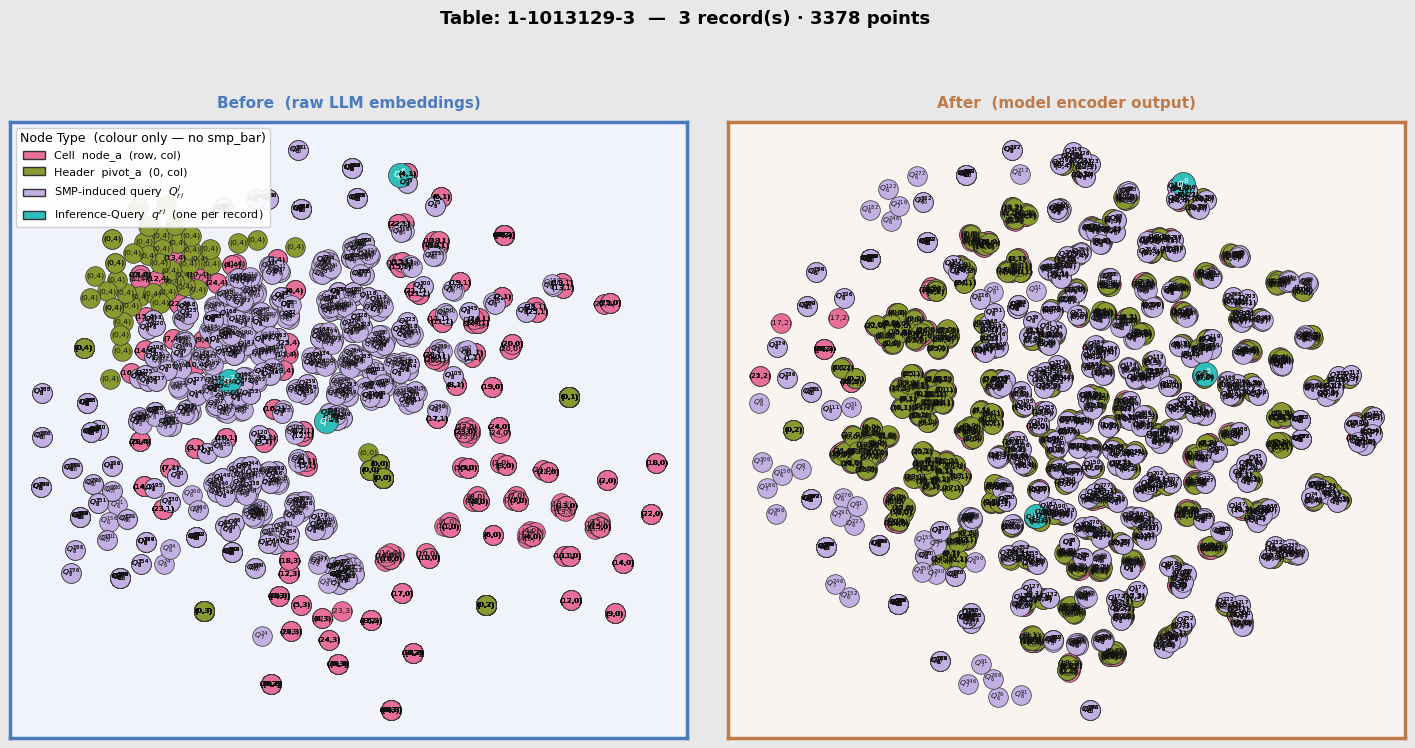

In [31]:
# ── § 8  Embedding space — single table, before vs. after ────────────────────
# Grid plot: 1 row × 2 cols, each panel enclosed in a visible border.
#
# COLOUR encodes node type; SHAPE encodes the encoder pass (SMP vs SMP_bar):
#   ○ circle   — node extracted from the SMP  encoder  (node_a, pivot_a)
#   ▲ triangle — node extracted from the SMP_bar encoder (node_b)
#   ◆ diamond  — query token (target encoder, SMP-induced)
#   ★ star     — inference question (target encoder)
#
# Colour key:
#   pink      → Cell  (node_a  SMP ○  |  node_b  SMP_bar ▲)
#   olive     → Header pivot_a (SMP ○)
#   lavender  → SMP-induced query  Q_{ri,j}
#   teal      → inference question q^{ri}

import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import matplotlib.lines   as mlines
from sklearn.manifold import TSNE

# ── Parameters ────────────────────────────────────────────────────────────────
VIZ_TABLE_ID = None      # str table_id to visualise, or None → auto-pick first
MAX_UPATHS   = None      # None = all U-paths; set an int to cap (e.g. 8)
TSNE_PERP    = 15
TSNE_ITER    = 1000
RAND_STATE   = 42

PANEL_BG = ["#f0f4fa", "#faf4f0"]   # blue-grey | warm-white

# Colour encodes type
TYPE_COLOR = {
    "Cell":     "#e76f9a",   # pink  — both node_a (SMP ○) and node_b (SMP_bar ▲)
    "Header":   "#8a9a30",   # olive
    "Query":    "#c2b0e3",   # lavender
    "Question": "#2ebfbc",   # teal
}
TYPE_SIZE = {
    "Cell": 200, "Header": 200, "Query": 200, "Question": 300,
}

# Shape encodes encoder source
SOURCE_MARKER = {
    "SMP":        "o",   # circle   — from SMP  encoder (node_a, pivot_a)
    "SMP_bar":    "^",   # triangle — from SMP_bar encoder (node_b)
    "target_enc": "D",   # diamond  — from target encoder (SMP queries)
    "inference":  "*",   # star     — inference question
}

# ── Resolve table ─────────────────────────────────────────────────────────────
_all_tids = [str(r.get("table_id", i)) for i, r in enumerate(ds.records)]
if VIZ_TABLE_ID is None:
    VIZ_TABLE_ID = _all_tids[6]

_tbl_rec_idxs = [i for i, tid in enumerate(_all_tids) if tid == VIZ_TABLE_ID]
assert _tbl_rec_idxs, f"table_id {VIZ_TABLE_ID!r} not found in ds.records"
print(f"Table  : {VIZ_TABLE_ID!r}  —  {len(_tbl_rec_idxs)} record(s)")

_tbl_model = (train_models.get(VIZ_TABLE_ID, train_model)
              if isinstance(train_models, dict) else train_model)
_tbl_model.eval().to(DEVICE)
_st = ds._st_model

# ── Collect vectors & metadata ────────────────────────────────────────────────
# meta entries: (label, type_key, source)
vecs_raw, vecs_enc, meta = [], [], []

for _ri in _tbl_rec_idxs:
    _rec      = ds.records[_ri]
    _all_idxs = [i for i, (r, _) in enumerate(ds._samples) if r == _ri]
    if not _all_idxs:
        continue
    _idxs = _all_idxs if MAX_UPATHS is None else _all_idxs[:MAX_UPATHS]
    _n    = len(_idxs)
    _it   = torch.tensor(_idxs, dtype=torch.long)
    _ups  = [ds._samples[i][1] for i in _idxs]

    _smp_raw = ds._embed_cache[ds._smp_idx[_it]].cpu()       # [n, 4, d_in]
    _qry_raw = ds._embed_cache[ds._qry_cat_idx[_it]].cpu()   # [n, d_in]
    _q_raw   = ds._question_cache[_ri].cpu()                  # [d_in]

    with torch.no_grad():
        # ── SMP: online encoder ───────────────────────────────────────────────
        _proj  = _tbl_model.input_projection(_smp_raw.to(DEVICE))
        _cls   = _tbl_model.cls_token.expand(_n, -1, -1)
        _enc_s, _, _ = _tbl_model.transformer_encoder(
            torch.cat([_cls, _proj], dim=1))
        _enc_na = F.normalize(_enc_s[:, 2, :], dim=-1).cpu()  # node_a @ pos 2
        _enc_ha = F.normalize(_enc_s[:, 1, :], dim=-1).cpu()  # pivot_a @ pos 1

        # ── SMP_bar: reverse SMP → online encoder → node_b at pos 2 ─────────
        _smp_bar_t = _smp_raw[:, [3, 2, 1, 0], :].to(DEVICE)
        _proj_b    = _tbl_model.input_projection(_smp_bar_t)
        _cls_b     = _tbl_model.cls_token.expand(_n, -1, -1)
        _enc_b, _, _ = _tbl_model.transformer_encoder(
            torch.cat([_cls_b, _proj_b], dim=1))
        _enc_nb = F.normalize(_enc_b[:, 2, :], dim=-1).cpu()  # node_b @ pos 2

        # ── Target encoder: SMP-induced query ─────────────────────────────────
        _qp  = _tbl_model.input_projection(_qry_raw.to(DEVICE).unsqueeze(1))
        _eq, _, _ = _tbl_model.target_encoder(_qp)
        _enc_qry = F.normalize(_eq[:, 0, :], dim=-1).cpu()

        # ── Target encoder: inference question ────────────────────────────────
        _q_t  = torch.tensor(
            _st.encode([_rec.get("question", "")], show_progress_bar=False),
            dtype=torch.float32).to(DEVICE)
        _qp_q = _tbl_model.input_projection(_q_t.unsqueeze(1))
        _eq_q, _, _ = _tbl_model.target_encoder(_qp_q)
        _enc_qinf = F.normalize(_eq_q[:, 0, :], dim=-1).cpu()   # [1, d_out]

    print(f"  record {_ri}  {_n} U-paths  question: \"{_rec.get('question', '')}\"")

    for _j, _up in enumerate(_ups):        # SMP: Cell node_a → "(row, col_a)"
        vecs_raw.append(_smp_raw[_j, 1].numpy())
        vecs_enc.append(_enc_na[_j].numpy())
        meta.append((f"({_up.tbl_row},{_up.col_idx_a})", "Cell", "SMP"))

    for _j, _up in enumerate(_ups):        # SMP_bar: Cell node_b → "(row, col_b)"
        vecs_raw.append(_smp_raw[_j, 2].numpy())   # raw node_b embed (SMP index 2)
        vecs_enc.append(_enc_nb[_j].numpy())
        meta.append((f"({_up.tbl_row},{_up.col_idx_b})", "Cell", "SMP_bar"))

    for _j, _up in enumerate(_ups):        # SMP: Header pivot_a → "(0, col_a)"
        vecs_raw.append(_smp_raw[_j, 0].numpy())
        vecs_enc.append(_enc_ha[_j].numpy())
        meta.append((f"(0,{_up.col_idx_a})", "Header", "SMP"))

    for _j in range(_n):                   # SMP-induced query (target encoder)
        vecs_raw.append(_qry_raw[_j].numpy())
        vecs_enc.append(_enc_qry[_j].numpy())
        meta.append((f"$Q_{{{_ri}}}^{{{_j}}}$", "Query", "target_enc"))

    # Inference question — one per record (target encoder)
    vecs_raw.append(_q_raw.numpy())
    vecs_enc.append(_enc_qinf[0].numpy())
    meta.append((f"$q^{{{_ri}}}$", "Question", "inference"))

# ── t-SNE ─────────────────────────────────────────────────────────────────────
N_pts = len(vecs_raw)
_perp = min(TSNE_PERP, max(2, N_pts // 3 - 1))
print(f"\nt-SNE on {N_pts} points  (perplexity={_perp}) …")
_tsne_kw = dict(n_components=2, perplexity=_perp, n_iter=TSNE_ITER,
                random_state=RAND_STATE, init="pca")
xy_raw = TSNE(**_tsne_kw).fit_transform(np.array(vecs_raw, dtype=np.float32))
xy_enc = TSNE(**_tsne_kw).fit_transform(np.array(vecs_enc, dtype=np.float32))
print("t-SNE done.")

# ── Grid plot: 1 row × 2 cols ─────────────────────────────────────────────────
fig, axes = plt.subplots(
    1, 2,
    figsize=(18, 8),
    facecolor="#e8e8e8",
    gridspec_kw={"wspace": 0.06},
)
fig.suptitle(
    f"Table: {VIZ_TABLE_ID}  —  {len(_tbl_rec_idxs)} record(s) · {N_pts} points  "
    f"[colour=type  |  shape: ○ SMP  ▲ SMP_bar  ◆ query  ★ question]",
    fontsize=12, fontweight="bold", y=1.02,
)

_panel_titles  = ["Before  (raw LLM embeddings)", "After  (model encoder output)"]
_border_colors = ["#4a7bbf", "#bf7a4a"]

# Render order: back-to-front so Question / Query sit on top
_RENDER_ORDER = [
    ("Cell",     "SMP"),
    ("Cell",     "SMP_bar"),
    ("Header",   "SMP"),
    ("Query",    "target_enc"),
    ("Question", "inference"),
]

for ax, xy, ptitle, bg, bc in zip(
    axes, [xy_raw, xy_enc], _panel_titles, PANEL_BG, _border_colors
):
    ax.set_facecolor(bg)
    for sp in ax.spines.values():
        sp.set_visible(True)
        sp.set_linewidth(2.5)
        sp.set_color(bc)

    ax.set_title(ptitle, fontsize=11, pad=10, color=bc, fontweight="bold")
    ax.set_xticks([]); ax.set_yticks([])

    for nt, src in _RENDER_ORDER:
        _col = TYPE_COLOR[nt]
        _sz  = TYPE_SIZE[nt]
        _mrk = SOURCE_MARKER[src]
        _ii  = [i for i, (_, t, s) in enumerate(meta) if t == nt and s == src]
        if not _ii:
            continue
        ax.scatter(xy[_ii, 0], xy[_ii, 1],
                   c=_col, marker=_mrk, s=_sz,
                   edgecolors="#333", linewidths=0.5, zorder=3)

    for i, (lbl, nt, src) in enumerate(meta):
        _is_q = (nt == "Question")
        ax.text(xy[i, 0], xy[i, 1], lbl,
                ha="center", va="center",
                fontsize=8 if _is_q else 5.5,
                fontweight="bold" if _is_q else "normal",
                color="white" if _is_q else "#111",
                zorder=4)

# ── Legend: colour × shape combined ──────────────────────────────────────────
_legend_handles = [
    mlines.Line2D([], [], color="#e76f9a", marker="o", linestyle="None",
                  markersize=9, markeredgecolor="#333",
                  label="Cell  node_a  (row, col_a)   [SMP  ○]"),
    mlines.Line2D([], [], color="#e76f9a", marker="^", linestyle="None",
                  markersize=9, markeredgecolor="#333",
                  label="Cell  node_b  (row, col_b)   [SMP_bar  ▲]"),
    mlines.Line2D([], [], color="#8a9a30", marker="o", linestyle="None",
                  markersize=9, markeredgecolor="#333",
                  label="Header  pivot_a  (0, col_a)  [SMP  ○]"),
    mlines.Line2D([], [], color="#c2b0e3", marker="D", linestyle="None",
                  markersize=9, markeredgecolor="#333",
                  label="Query  $Q_{ri}^{j}$  [target enc.  ◆]"),
    mlines.Line2D([], [], color="#2ebfbc", marker="*", linestyle="None",
                  markersize=13, markeredgecolor="#333",
                  label="Question  $q^{ri}$  [inference  ★]"),
]
axes[0].legend(handles=_legend_handles,
               title="Type (colour)  ×  Source (shape)",
               loc="upper left", fontsize=8, title_fontsize=9,
               framealpha=0.92, facecolor="white")

plt.tight_layout()
plt.show()
